# Module 2.4 — Pressure-Velocity Coupling

**The central problem of incompressible CFD:**
The N-S momentum equations need pressure to advance the velocity. But there is no equation for pressure — it is determined by the requirement that velocity must be divergence-free. Pressure and velocity are coupled through the incompressibility constraint. Solving this coupling is the core challenge of incompressible CFD.

**This module answers three questions:**
1. Why does naively putting $p$ and $\mathbf{u}$ on the same grid cause a catastrophic bug (checkerboard modes)?
2. How does the staggered grid fix this?
3. How is the pressure Poisson equation derived and solved?

**Roadmap:**
1. The pressure-velocity coupling problem — chicken and egg
2. The checkerboard bug — what it is and why it is invisible in residuals
3. The staggered MAC grid — the fix
4. The pressure Poisson equation — derived from continuity + momentum
5. Solving the Poisson equation — iterative methods
6. Connection to SIMPLE

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Coupling Problem — Chicken and Egg

### What you want to do

At each time step, you want to:
1. Advance velocity using momentum: $\mathbf{u}^{n+1} = f(\mathbf{u}^n, p^n)$
2. Update pressure so that $\nabla\cdot\mathbf{u}^{n+1} = 0$

The problem: to compute $p$, you need $\mathbf{u}$. To compute $\mathbf{u}$, you need $p$.

### Why there is no "pressure equation" in incompressible flow

In compressible flow: $p = \rho R T$ — equation of state directly gives $p$ from $\rho$ and $T$.

In incompressible flow: $\rho = $ const, temperature decoupled. There is **no equation of state** for $p$. Pressure is determined **only** by the requirement that the velocity field satisfies $\nabla\cdot\mathbf{u}=0$.

Think of pressure as the enforcer: whenever the velocity field starts to violate continuity, pressure instantly adjusts to push it back. This is why pressure changes propagate at infinite speed in incompressible flow — the enforcement is instantaneous.

### The consequence for numerical schemes

You cannot update $\mathbf{u}$ and $p$ independently. They must be solved together — or in a predictor-corrector loop (SIMPLE, Module 2.5). The pressure correction problem is what makes incompressible CFD harder than compressible CFD.

## 2. The Checkerboard Problem — A Fatal Discretisation Bug

### The setup

Suppose you store $u$, $v$, and $p$ all at the same cell-centre positions. This is called a **co-located** grid. It seems natural — one value per variable per cell.

Now discretise the pressure gradient in x-momentum using central differences:

$$\frac{\partial p}{\partial x}\bigg|_i \approx \frac{p_{i+1} - p_{i-1}}{2\Delta x}$$

Notice: this uses $p_{i+1}$ and $p_{i-1}$ — it **skips** $p_i$. The pressure at the point $i$ has no effect on the pressure gradient at $i$.

### The catastrophe

A checkerboard pressure field:
$$p_i = (-1)^i \cdot A$$

has the property that $p_{i+1} - p_{i-1} = (-1)^{i+1}A - (-1)^{i-1}A = 0$. The gradient of a wildly oscillating pressure is computed as **zero** by the central difference formula.

The solver cannot "see" this pressure mode. It satisfies the discrete momentum equation (zero gradient = zero force) while being physically meaningless. Once excited, the checkerboard mode persists forever — it is a **spurious mode** of the discrete system.

**The divergence check doesn't help:** the same skipping pattern in the divergence computation means the spurious velocity field $v_i = (-1)^i$ also has zero computed divergence. Both bugs are invisible to each other.

## 3. The Staggered MAC Grid — The Fix

Harlow & Welch (1965) invented the **Marker-and-Cell (MAC) grid**:
- $p$: stored at cell **centres**
- $u$ (x-velocity): stored at **x-face centres** (midpoint of East and West faces)
- $v$ (y-velocity): stored at **y-face centres** (midpoint of North and South faces)

```
       v_{j+1/2, i}         ← v lives here (North face centre)
            ↑
u_{j,i-1/2} ←  p_{j,i}  → u_{j,i+1/2}    ← u lives on x-faces
            ↓
       v_{j-1/2, i}         ← v lives here (South face centre)
```

**Why this fixes the checkerboard:**

Pressure gradient at the x-face: uses $p$ at the **two adjacent cell centres** (no skipping):

$$\frac{\partial p}{\partial x}\bigg|_{i+1/2} = \frac{p_{i+1} - p_i}{\Delta x}$$

The checkerboard mode $p_i = (-1)^i$ now gives gradient $= (-1)^{i+1} - (-1)^i = \pm 2 \neq 0$ — the solver **can** see it and will damp it out.

**Continuity on the staggered grid:** uses u-values at x-faces and v-values at y-faces — again no skipping:

$$\nabla\cdot\mathbf{u}\bigg|_{j,i} = \frac{u_{j,i+1/2} - u_{j,i-1/2}}{\Delta x} + \frac{v_{j+1/2,i} - v_{j-1/2,i}}{\Delta y}$$

=== Checkerboard pressure: p = (-1)^i ===

Co-located central difference dp/dx at interior points:
[0. 0. 0. 0. 0. 0. 0. 0.]
  → Max |dp/dx| = 0.00  ← ZERO! Solver cannot see the oscillation.

Staggered dp/dx at face centres:
[-2.  2. -2.  2. -2.  2. -2.  2. -2.]
  → Max |dp/dx| = 2.00  ← ±2. Solver CAN see and correct the oscillation.


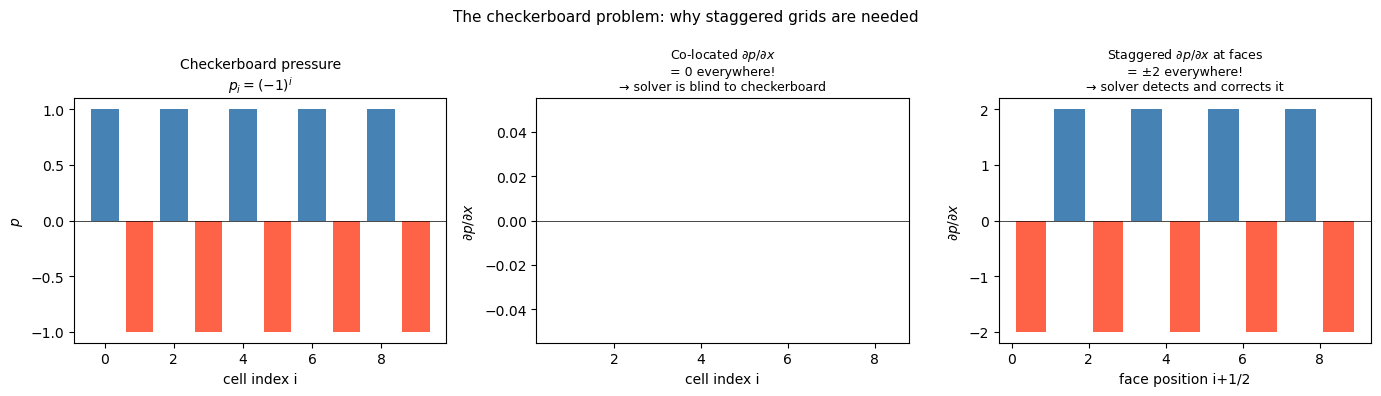

In [2]:
# ── Demonstrate the checkerboard problem ─────────────────────────────────────
# On a co-located grid, a checkerboard pressure field has zero computed gradient.
# On a staggered grid, the same field has a large non-zero gradient — detectable.

N = 10   # small grid for clear visualisation
i = np.arange(N)

# ── Checkerboard pressure: p_i = (-1)^i ──────────────────────────────────────
p = (-1.0) ** i

# ── Co-located central difference: dp/dx at point i ──────────────────────────
# Uses p[i+1] and p[i-1] — skips p[i]
dpdx_collocated = np.zeros(N)
dpdx_collocated[1:-1] = (p[2:] - p[:-2]) / 2.0   # central diff on same grid

# ── Staggered: dp/dx at face i+1/2 ───────────────────────────────────────────
# Uses p[i] and p[i+1] — adjacent cells, no skipping
dpdx_staggered = p[1:] - p[:-1]   # face gradient = right cell - left cell
faces = np.arange(N-1) + 0.5      # face positions

print('=== Checkerboard pressure: p = (-1)^i ===')
print()
print('Co-located central difference dp/dx at interior points:')
print(dpdx_collocated[1:-1])
print(f'  → Max |dp/dx| = {np.max(np.abs(dpdx_collocated)):.2f}  ← ZERO! Solver cannot see the oscillation.')
print()
print('Staggered dp/dx at face centres:')
print(dpdx_staggered)
print(f'  → Max |dp/dx| = {np.max(np.abs(dpdx_staggered)):.2f}  ← ±2. Solver CAN see and correct the oscillation.')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Checkerboard pressure
axes[0].bar(i, p, width=0.8, color=['steelblue' if pi > 0 else 'tomato' for pi in p])
axes[0].set_title('Checkerboard pressure\n$p_i = (-1)^i$', fontsize=10)
axes[0].set_xlabel('cell index i'); axes[0].set_ylabel('$p$')
axes[0].axhline(0, color='k', lw=0.5)

# Co-located gradient (should see oscillation, but doesn't)
axes[1].bar(i[1:-1], dpdx_collocated[1:-1], width=0.8, color='grey', alpha=0.7)
axes[1].set_title('Co-located $\\partial p/\\partial x$\n= 0 everywhere!\n→ solver is blind to checkerboard', fontsize=9)
axes[1].set_xlabel('cell index i'); axes[1].set_ylabel('$\\partial p/\\partial x$')
axes[1].axhline(0, color='k', lw=0.5)

# Staggered gradient (correctly detects the oscillation)
axes[2].bar(faces, dpdx_staggered, width=0.8, color=['steelblue' if g > 0 else 'tomato' for g in dpdx_staggered])
axes[2].set_title('Staggered $\\partial p/\\partial x$ at faces\n= ±2 everywhere!\n→ solver detects and corrects it', fontsize=9)
axes[2].set_xlabel('face position i+1/2'); axes[2].set_ylabel('$\\partial p/\\partial x$')
axes[2].axhline(0, color='k', lw=0.5)

plt.suptitle('The checkerboard problem: why staggered grids are needed', fontsize=11)
plt.tight_layout()
plt.show()

Poisson solver converged in 2000 iterations
Max error vs exact: 3.4461e-01

Note: Gauss-Seidel is slow for large N.
Production codes use multigrid (Module 3.5) which reduces this to O(N) iterations.


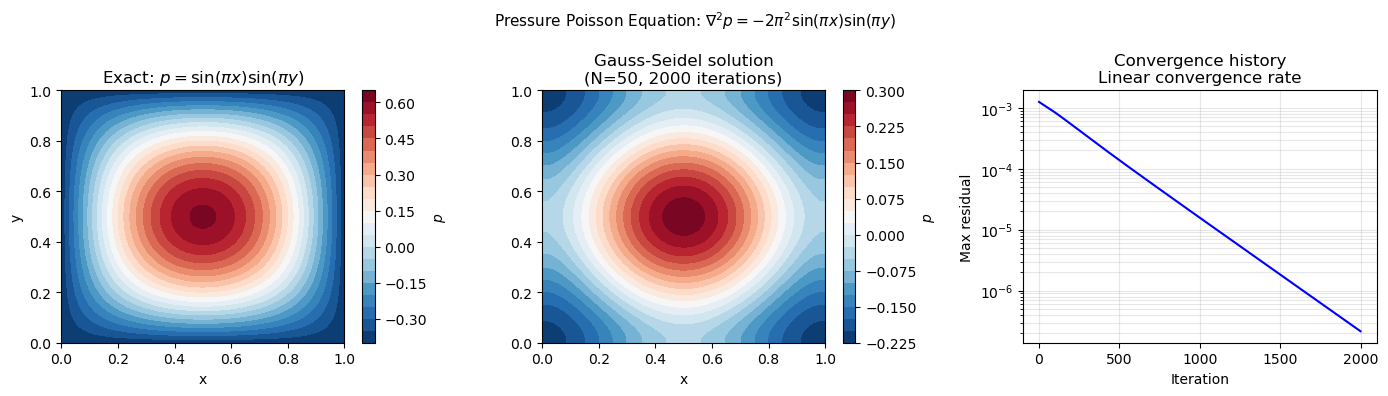

In [3]:
# ── Solving the Pressure Poisson Equation ─────────────────────────────────────
# ∇²p = RHS on [0,1]×[0,1] with Neumann BCs (dp/dn=0 on all walls)
# Manufactured solution: p = sin(πx)sin(πy), RHS = -2π²sin(πx)sin(πy)
#
# Solver: Gauss-Seidel iteration (simple but illustrative)
# Each iteration sweeps through all interior cells updating:
#   p[j,i] = (neighbours/Δ² - rhs) / (2/dx² + 2/dy²)

def solve_poisson_GS(rhs, dx, dy, niter=2000, tol=1e-8):
    """
    Gauss-Seidel solver for ∇²p = rhs.
    Neumann BCs: zero-gradient (dp/dn = 0) on all boundaries.
    Returns p and convergence history.
    """
    p   = np.zeros_like(rhs)
    res = []

    for it in range(niter):
        p_old = p.copy()

        # ── Interior update ───────────────────────────────────────────────────
        p[1:-1, 1:-1] = (
            (p[1:-1, 2:] + p[1:-1, :-2]) / dx**2 +
            (p[2:, 1:-1] + p[:-2, 1:-1]) / dy**2 -
            rhs[1:-1, 1:-1]
        ) / (2/dx**2 + 2/dy**2)

        # ── Neumann BCs: zero gradient → ghost cell = adjacent interior cell ──
        p[0,  :] = p[1,  :]
        p[-1, :] = p[-2, :]
        p[:,  0] = p[:,  1]
        p[:, -1] = p[:, -2]

        # ── Remove mean (PPE is only unique up to a constant) ─────────────────
        p -= p.mean()

        r = np.max(np.abs(p - p_old))
        res.append(r)
        if r < tol:
            break

    return p, res

# ── Setup ────────────────────────────────────────────────────────────────────
N  = 50
dx = dy = 1.0 / (N-1)
x  = np.linspace(0, 1, N)
y  = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

rhs   = -2 * np.pi**2 * np.sin(np.pi*X) * np.sin(np.pi*Y)
exact = np.sin(np.pi*X) * np.sin(np.pi*Y)
exact -= exact.mean()   # remove mean for fair comparison

p_sol, history = solve_poisson_GS(rhs, dx, dy)

err = np.max(np.abs(p_sol - exact))
print(f'Poisson solver converged in {len(history)} iterations')
print(f'Max error vs exact: {err:.4e}')
print()
print('Note: Gauss-Seidel is slow for large N.')
print('Production codes use multigrid (Module 3.5) which reduces this to O(N) iterations.')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cf1 = axes[0].contourf(X, Y, exact, levels=20, cmap='RdBu_r')
plt.colorbar(cf1, ax=axes[0], label='$p$')
axes[0].set_title('Exact: $p = \\sin(\\pi x)\\sin(\\pi y)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

cf2 = axes[1].contourf(X, Y, p_sol, levels=20, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[1], label='$p$')
axes[1].set_title(f'Gauss-Seidel solution\n(N={N}, {len(history)} iterations)')
axes[1].set_xlabel('x')

axes[2].semilogy(history, 'b-', lw=1.5)
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Max residual')
axes[2].set_title('Convergence history\nLinear convergence rate')
axes[2].grid(True, which='both', alpha=0.3)

plt.suptitle('Pressure Poisson Equation: $\\nabla^2 p = -2\\pi^2\\sin(\\pi x)\\sin(\\pi y)$', fontsize=11)
plt.tight_layout()
plt.show()

## Summary

| Problem | Cause | Fix |
|---------|-------|-----|
| Pressure-velocity coupling | No direct equation for $p$ in incompressible N-S | Pressure Poisson equation from divergence of momentum |
| Checkerboard pressure | Co-located grid: central diff skips adjacent cells | Staggered grid (MAC): $u, v, p$ at different locations |
| Checkerboard velocity | Same skipping in continuity equation | Staggered grid automatically prevents this |
| PPE non-unique | Pressure determined up to a constant | Pin pressure at one point or remove mean |

**Key connection to SIMPLE (next module):**
SIMPLE solves the pressure-velocity coupling iteratively:
1. Solve momentum with guessed pressure → get $\mathbf{u}^*$ (not divergence-free)
2. Solve the PPE for a pressure correction $p'$ that makes $\mathbf{u}^*$ divergence-free
3. Correct $\mathbf{u}$ and $p$
4. Repeat until converged

---
**Next:** Module 2.5 — SIMPLE Algorithm: step-by-step derivation and implementation.

## Exercise

**Predict first, then verify.**

1. On a 4×4 co-located grid, create a checkerboard velocity field $u_{j,i} = (-1)^{i+j}$. Compute the numerical divergence using central differences. What do you get? Now compute it using staggered-grid differences (use values at faces). What changes?

2. Modify the Poisson solver to use **Jacobi iteration** instead of Gauss-Seidel (compute all new values from the old array, then update). How does the convergence rate change? Look at the slope of the residual history — which method converges faster?

3. The PPE must be solved at every time step of a CFD simulation. If the Poisson solver takes 500 iterations to converge and you have 10,000 time steps, how many Poisson iterations total? Is this a problem? (This motivates multigrid in Module 3.5.)